# Introduce Missingness

In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname('src'), '..')))

from src.constants import SEED, IRIS_DATASET_ID
from src.datasets import load_openml_dataset
from src.missingness import *
from src.visualize import *

## Iris Dataset
Load the Iris dataset as an example

In [2]:
IRIS_DATASET = load_openml_dataset(IRIS_DATASET_ID)
print(IRIS_DATASET)

     sepallength  sepalwidth  petallength  petalwidth           class
0            5.1         3.5          1.4         0.2     Iris-setosa
1            4.9         3.0          1.4         0.2     Iris-setosa
2            4.7         3.2          1.3         0.2     Iris-setosa
3            4.6         3.1          1.5         0.2     Iris-setosa
4            5.0         3.6          1.4         0.2     Iris-setosa
..           ...         ...          ...         ...             ...
145          6.7         3.0          5.2         2.3  Iris-virginica
146          6.3         2.5          5.0         1.9  Iris-virginica
147          6.5         3.0          5.2         2.0  Iris-virginica
148          6.2         3.4          5.4         2.3  Iris-virginica
149          5.9         3.0          5.1         1.8  Iris-virginica

[150 rows x 5 columns]


## Introduce Missingness
Apply each type of data corruption (MCAR, MNAR, MAR) to the Iris dataset for testing TDA robustness


In [3]:
corrupted_iris_umcar = univariat_mcar(IRIS_DATASET, "sepalwidth", "class", 10, seed=SEED)
corrupted_iris_mmcar = multivariat_mcar(IRIS_DATASET, "class", 10, seed=SEED)
corrupted_iris_umnar = univariat_mnar(IRIS_DATASET, "sepalwidth", "class", 0)
corrupted_iris_mmnar = multivariat_mnar(IRIS_DATASET, "class", 0)
corrupted_iris_umar = univariat_mar(IRIS_DATASET, "petalwidth", "petallength", "class", 10)
corrupted_iris_mmar = multivariat_mar(IRIS_DATASET, "class", 4)

# Univariat MCAR - Missing Completely At Random
Missing values in a single feature (sepalwidth) are randomly distributed.

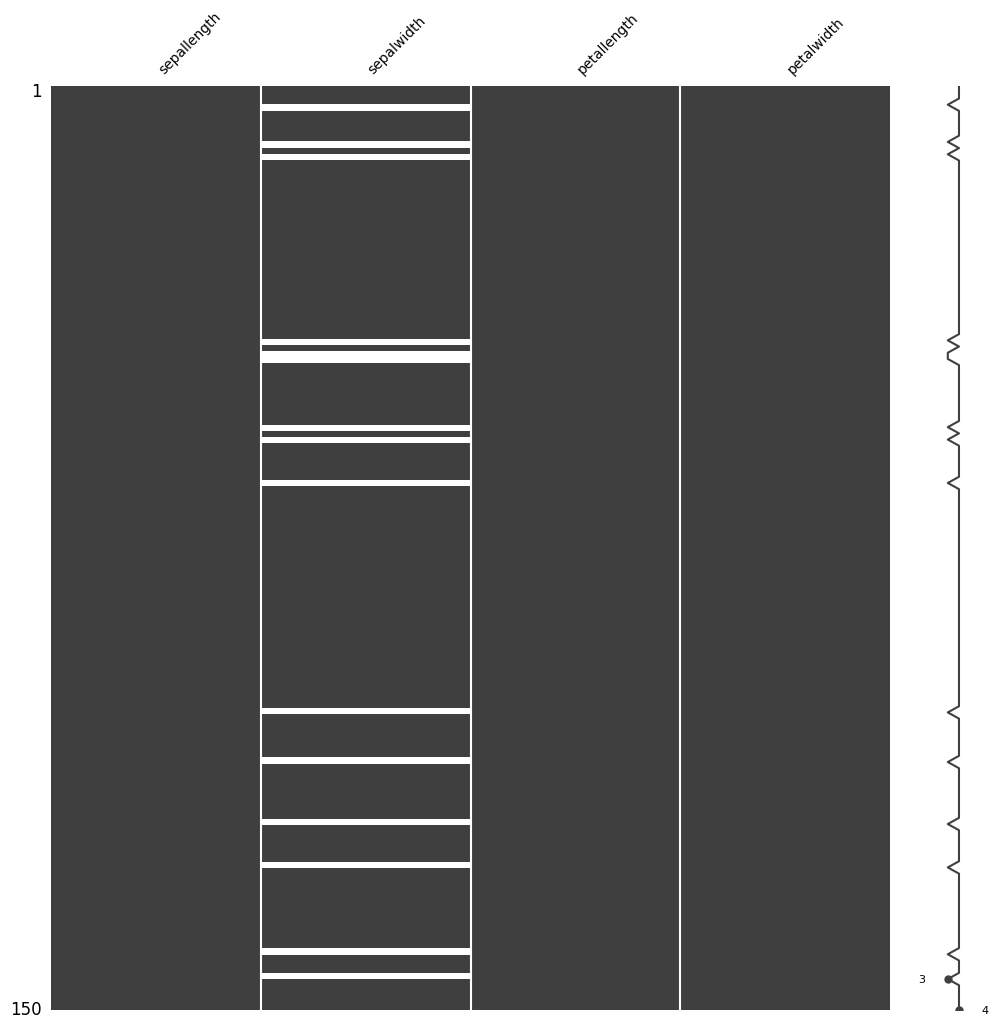

In [4]:
plot_missing_data(IRIS_DATASET, corrupted_iris_umcar)

# Multivariat MCAR - Missing Completely At Random
Missing values in one or more features are randomly distributed across the dataset.

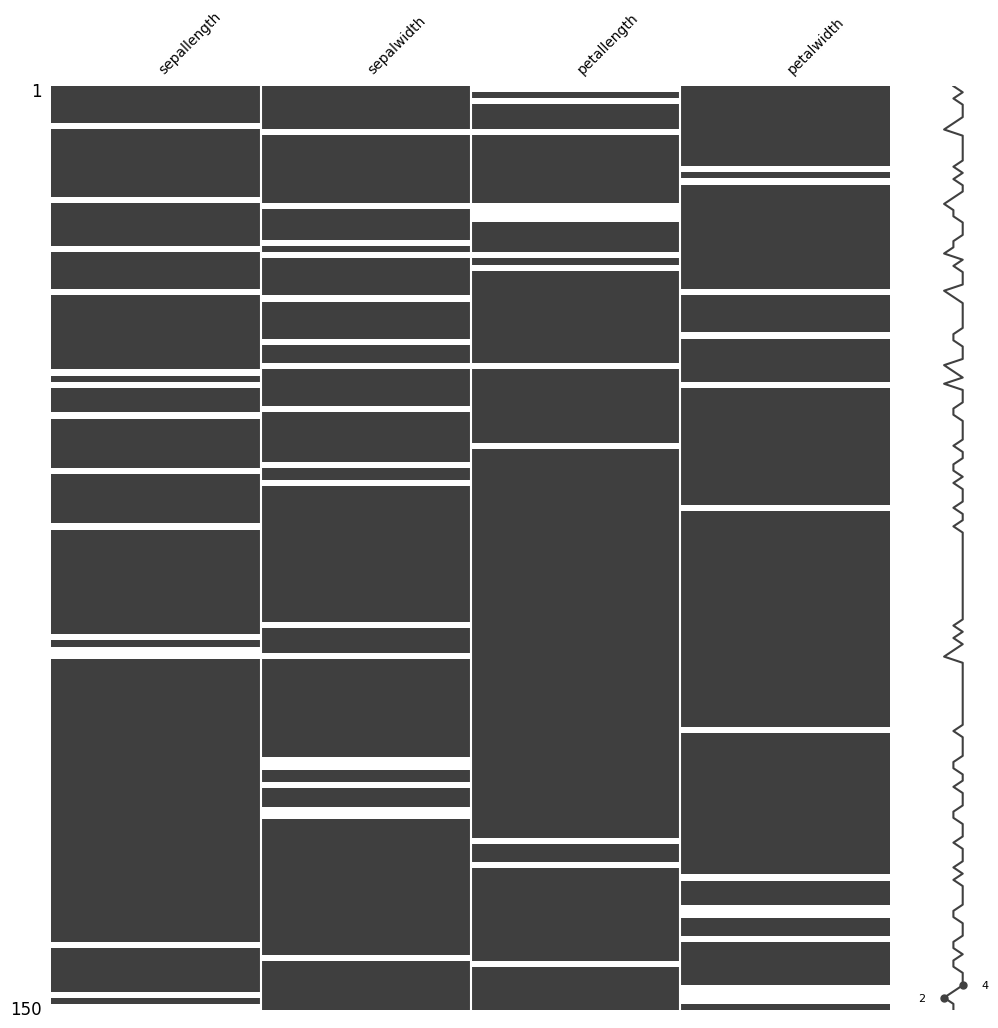

In [5]:
plot_missing_data(IRIS_DATASET, corrupted_iris_mmcar)

# Univariat MNAR - Missing Not At Random
Missing values in a single feature (sepalwidth) depend on the values of the target variable, meaning the probability of missingness is systematically related to unobserved outcomes.

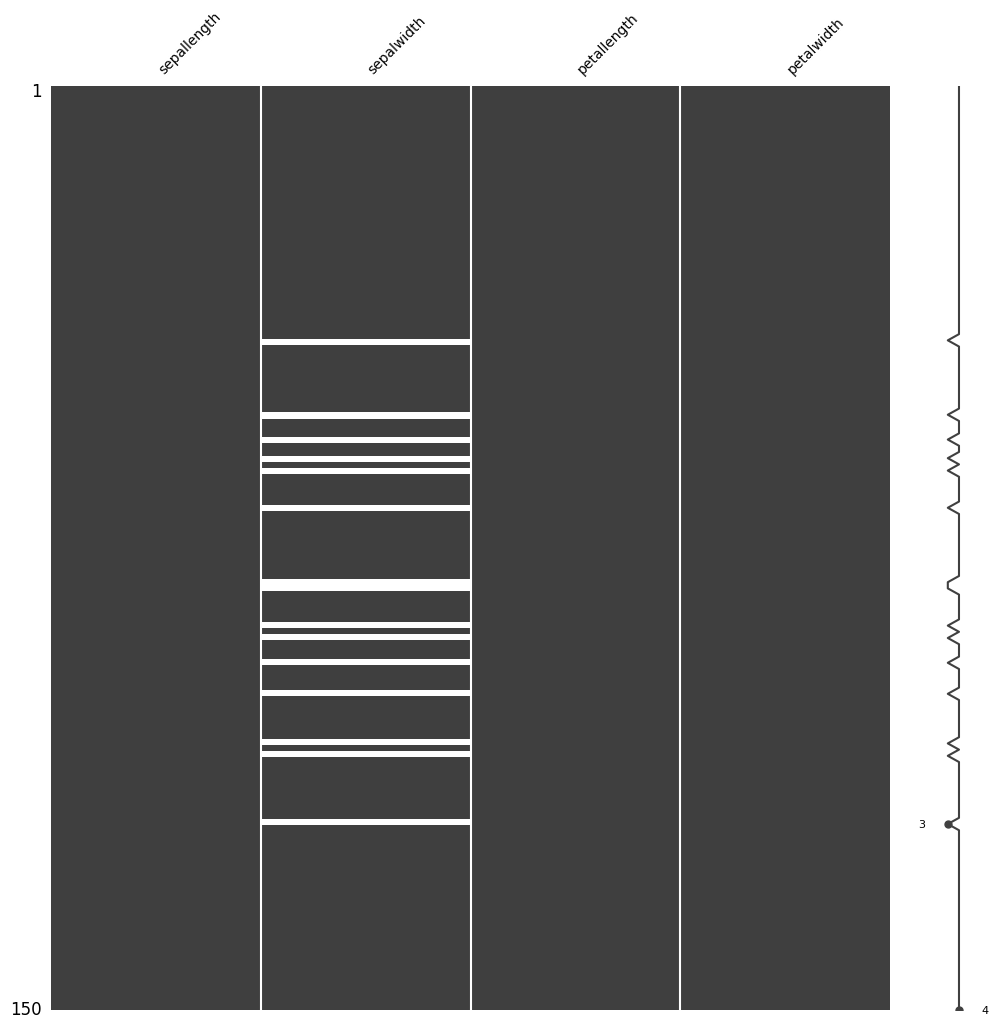

In [6]:
plot_missing_data(IRIS_DATASET, corrupted_iris_umnar)

# Multivariat MNAR - Missing Not At Random
Missing values across multiple features depend on the values of the target variable, meaning the likelihood of missingness is systematically related to unobserved outcomes in the dataset.

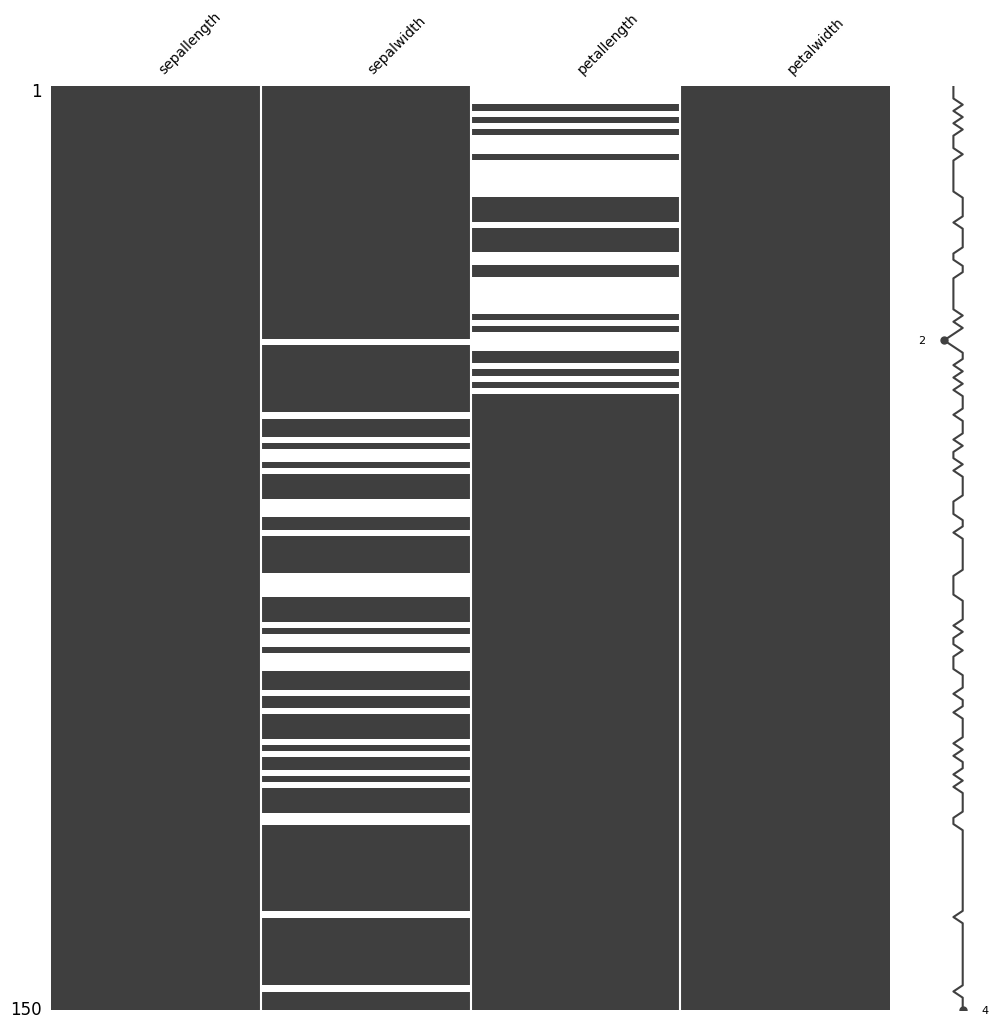

In [7]:
plot_missing_data(IRIS_DATASET, corrupted_iris_mmnar)

# Univariat MAR - Missing At Random
Missing values in a single feature (petalwidth) depend on the values of another observed variable in the dataset (petallength), meaning the probability of missingness is systematically related to known information.

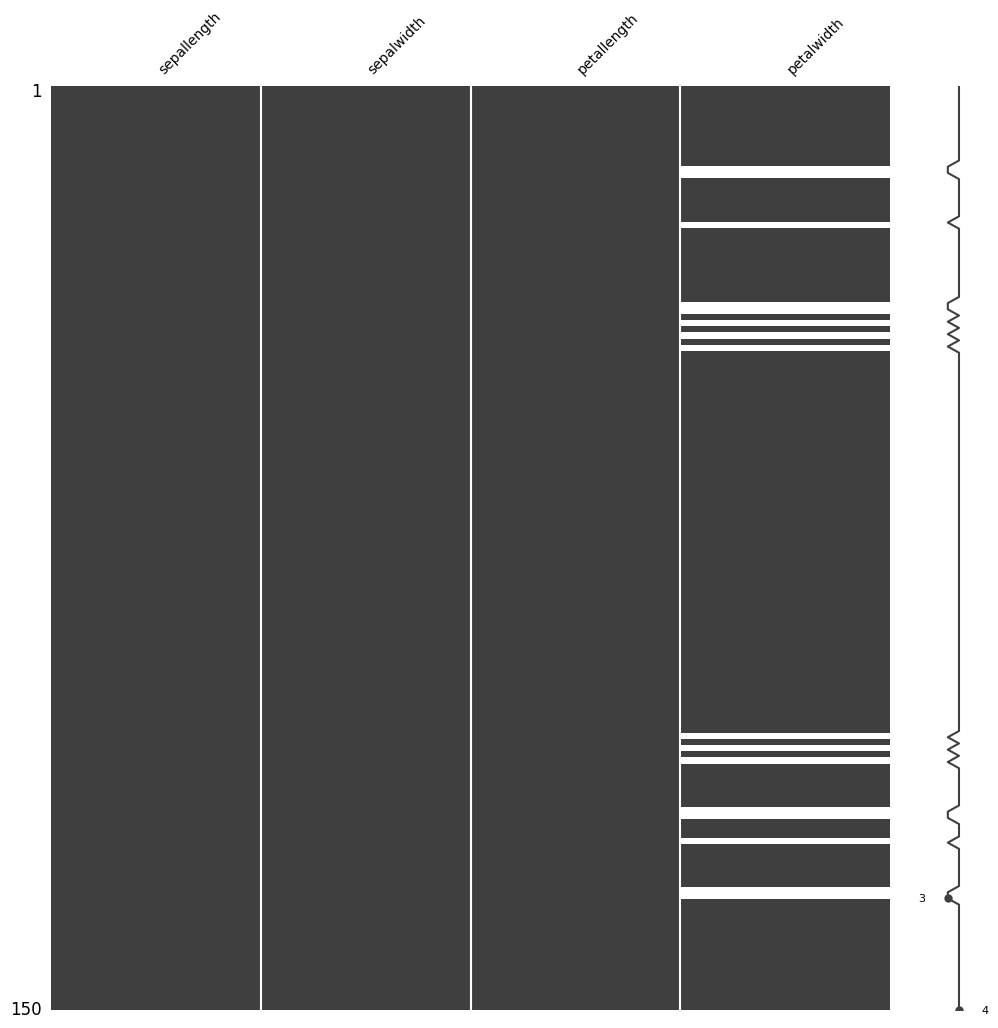

In [8]:
plot_missing_data(IRIS_DATASET, corrupted_iris_umar)

# Multivariat MAR - Missing At Random
Missing values across multiple features depend on the values of other observed variables in the dataset, meaning the probability of missingness is systematically related to known information.

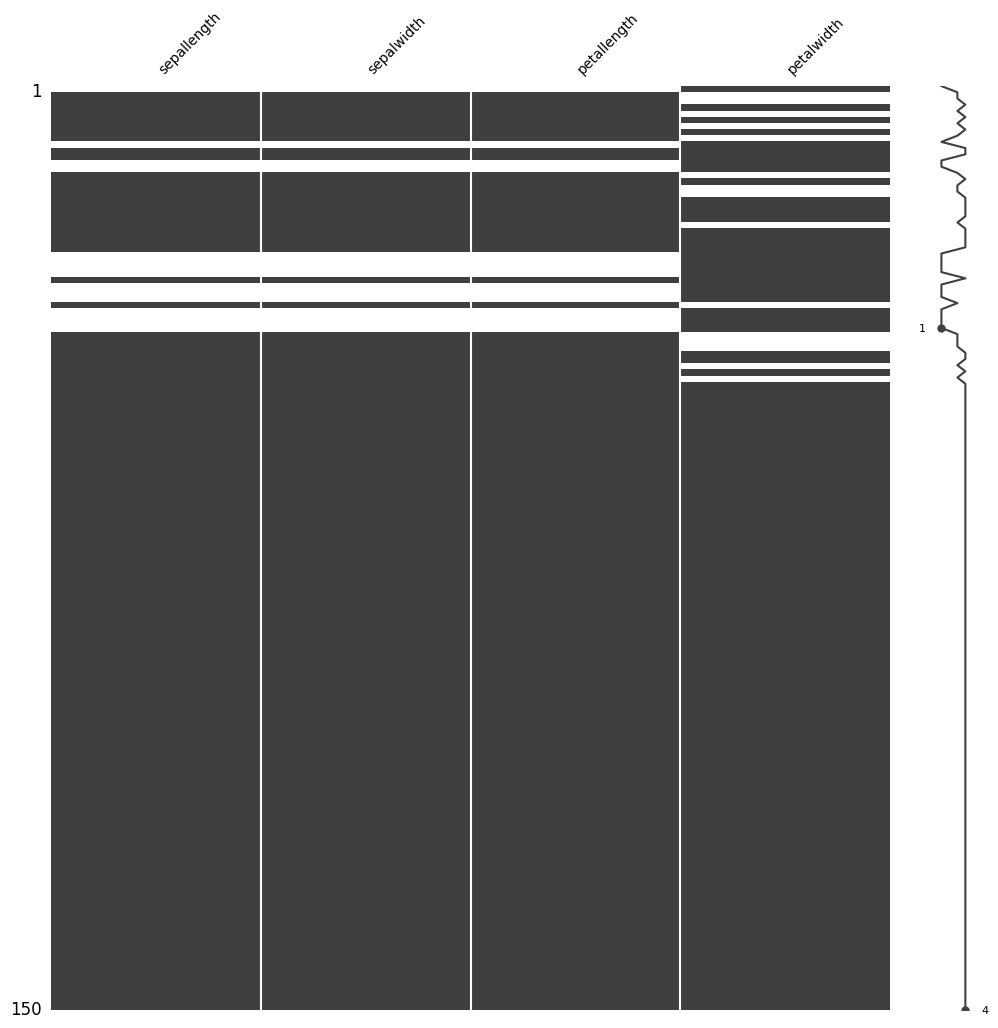

In [9]:
plot_missing_data(IRIS_DATASET, corrupted_iris_mmar)